In [1]:
# Load AG News dataset
from datasets import load_dataset
ds = load_dataset("fancyzhx/ag_news")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [3]:
import pandas as pd
df = pd.DataFrame(ds["train"])

# Basic info
print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns)
df.head()


Dataset shape: (120000, 2)

Columns: Index(['text', 'label'], dtype='object')


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [4]:
# Sample the dataset
import numpy as np

np.random.seed(42)
# Sample size
SAMPLE_SIZE = 5000
# Randomly sample from the dataset
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# Verify result
print("Sampled dataset shape:", df_sample.shape)
df_sample.head()

Sampled dataset shape: (5000, 2)


,text,label
0,"BBC set for major shake-up, claims newspaper L...",2
1,Marsh averts cash crunch Embattled insurance b...,2
2,"Jeter, Yankees Look to Take Control (AP) AP - ...",1
3,Flying the Sun to Safety When the Genesis caps...,3
4,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,2


In [5]:
# Convert text to TF-IDF features
# TF-IDF converts each article into a numerical representation that captures the importance of words relative to the entire corpus.
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer
tfidf = TfidfVectorizer(stop_words="english", max_df=0.8, min_df=5)

# Fit and transform the text data
X_tfidf = tfidf.fit_transform(df_sample["text"])

# Check result
print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (5000, 4232)


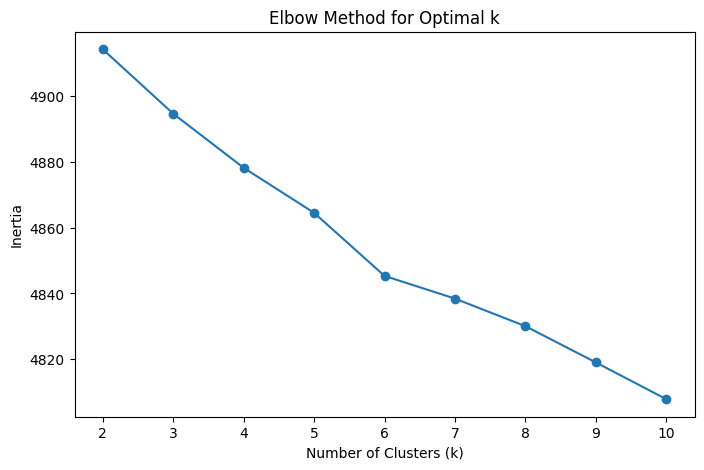

In [6]:
# Elbow Method to determine optimal k
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_tfidf)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

#The Elbow Method was used to determine the appropriate number of clusters by analyzing the trade-off between the number of clusters and within-cluster variance.

In [7]:
# K-Means clustering with k = 5 (comparison)

K_TEST = 5

kmeans_5 = KMeans(n_clusters=K_TEST, random_state=42, n_init=10)
cluster_labels_5 = kmeans_5.fit_predict(X_tfidf)

df_sample["cluster_k5"] = cluster_labels_5

# Inspect cluster distribution
print("Cluster distribution for k = 5:")
print(df_sample["cluster_k5"].value_counts().sort_index())


Cluster distribution for k = 5:
cluster_k5
0    3002
1     334
2    1307
3     138
4     219
Name: count, dtype: int64


In [ ]:
"""
Although k = 5 was evaluated, the resulting cluster distribution was highly imbalanced,
with several very small clusters that did not correspond to distinct topics.

This indicates over-clustering. Therefore, k = 4 was selected as the final number of clusters.
"""

In [8]:
# Remove k=5 column
df_sample.drop(columns=["cluster_k5"], inplace=True, errors="ignore")

In [9]:
# Fit final k=4 model
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_sample["cluster"] = kmeans_4.fit_predict(X_tfidf)

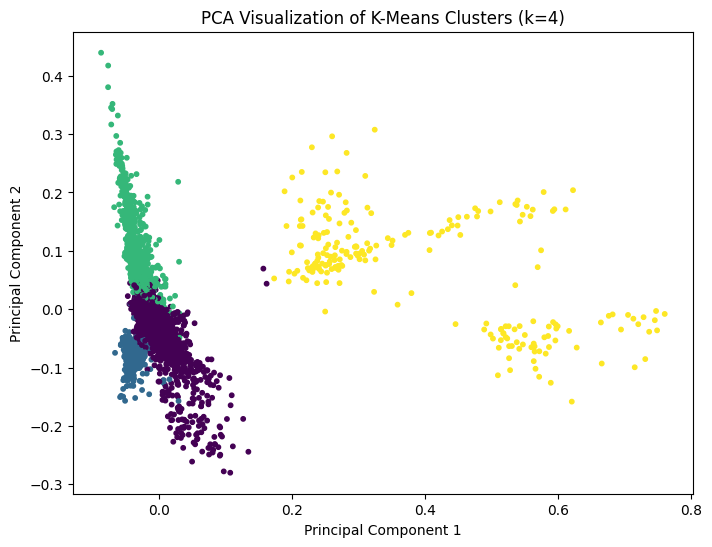

In [10]:
# Visualize clusters using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

# Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_sample["cluster"], s=10)
plt.title("PCA Visualization of K-Means Clusters (k=4)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [11]:
#Extract top keywords for each cluster
feature_names = np.array(tfidf.get_feature_names_out())

for cluster_id in range(4):
    print(f"\nCluster {cluster_id} - Top Keywords:")

    # Get indices of points in this cluster
    cluster_indices = np.where(df_sample["cluster"] == cluster_id)[0]

    # Compute mean TF-IDF score for each term in the cluster
    mean_tfidf = X_tfidf[cluster_indices].mean(axis=0)

    # Convert to array and get top terms
    top_indices = np.asarray(mean_tfidf).flatten().argsort()[-10:][::-1]
    top_words = feature_names[top_indices]

    print(", ".join(top_words))


Cluster 0 - Top Keywords:
reuters, new, said, oil, year, world, monday, prices, wednesday, tuesday

Cluster 1 - Top Keywords:
ap, bush, 151, said, game, kerry, new, night, saturday, victory

Cluster 2 - Top Keywords:
39, quot, new, said, world, game, yesterday, year, night, company

Cluster 3 - Top Keywords:
gt, lt, fullquote, reuters, http, href, www, ticker, stocks, quickinfo


In [12]:
# Show example articles from each cluster
for cluster_id in range(4):
    print(f"\nCluster {cluster_id} - Sample Articles:")
    samples = df_sample[df_sample["cluster"] == cluster_id]["text"].head(3)
    for text in samples:
        print("-", text[:120], "...")


Cluster 0 - Sample Articles:
- Marsh averts cash crunch Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to  ...
- Flying the Sun to Safety When the Genesis capsule comes back to Earth with its samples of the sun, helicopter pilots wil ...
- Inter Milan seeks redemption win against Juventus It is early in the season for a decisive match, yet Inter Milan-Juvent ...

Cluster 1 - Sample Articles:
- Jeter, Yankees Look to Take Control (AP) AP - Derek Jeter turned a season that started with a terrible slump into one of ...
- O'Brien Sues OSU for  #36;3.4 Million (AP) AP - Former Ohio State basketball coach Jim O'Brien sued the school, claiming ...
- New Florida Coach Meyer Names Coaches (AP) AP - Florida coach Urban Meyer nearly filled out his coaching staff Monday, k ...

Cluster 2 - Sample Articles:
- BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the world #39;s biggest publ ...
- MSN #39;s download 

In [ ]:
"""
The resulting clusters are not perfectly distinct, which reflects the overlapping nature of real-world news topics.
Several high-frequency words related to news sources and formatting (e.g., “Reuters”, “AP”) appear across clusters, which reduces topic purity.
Despite this, certain clusters—such as sports and financial news—exhibit clear thematic coherence
"""

In [13]:
# Supervised prediction of clusters
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Prepare TF-IDF features for test set
X_test_tfidf = tfidf.transform(ds["test"]["text"])

# Assign cluster labels to test data using trained k-means (k=4)
test_cluster_labels = kmeans_4.predict(X_test_tfidf)

# Supervised training data (train split)
X_train = X_tfidf
y_train = df_sample["cluster"]

# Supervised test data (test split)
X_test = X_test_tfidf
y_test = test_cluster_labels

# Train supervised classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predict clusters on test set
y_pred = clf.predict(X_test)

# Evaluation
print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy on test set: 0.9719736842105263

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      5225
           1       1.00      0.97      0.98       510
           2       0.99      0.88      0.93      1569
           3       1.00      0.96      0.98       296

    accuracy                           0.97      7600
   macro avg       0.99      0.95      0.97      7600
weighted avg       0.97      0.97      0.97      7600



In [ ]:
"""
The supervised classifier achieved an accuracy of approximately 97% when predicting cluster assignments on the test set.
This indicates that the clusters produced by K-Means are internally consistent and can be reliably learned from textual features.
However, high predictive accuracy does not imply that clusters perfectly correspond to real-world categories, as some clusters contain overlapping or mixed topics.
"""